# Real World Classification

## Task 0: Load data

Import the necessary libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np

seed=42
np.random.seed(seed)

load the data

In [2]:
# Load data from NYCU_Iris.csv
import pandas as pd
df = pd.read_csv('data/NYCU_Iris.csv')
df.head()


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,IrrelevantFeature,Species
0,1,7.0,3.2,4.7,1.4,16.9,37.5,Iris-versicolor
1,2,6.4,3.2,4.5,1.5,16.4,95.1,Iris-versicolor
2,3,6.9,3.1,4.9,1.5,16.9,73.2,Iris-versicolor
3,4,5.5,2.3,0.7,1.3,15.6,59.9,Iris-versicolor
4,5,6.5,2.8,4.6,1.5,16.4,15.6,Iris-versicolor


## Task 1: Preprocessing

In [ ]:
from sklearn.preprocessing import LabelEncoder
feature_cols = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm','BranchLength']

def data_preprocessing(df):
    # transform label to bi-class
    df['Species'] = df['Species'].astype(str).str.strip()
    le = LabelEncoder()
    df['Species'] = le.fit_transform(df['Species'])

    # transform string to number
    for col in feature_cols:
        df[col] = pd.to_numeric(df[col])
    
    # TODO: Drop the missing values, outliers and normalize the data to [0,1]
    # ---------- Start your code below ----------


    # ---------- --------------------- ----------
        
    return df

df = data_preprocessing(df)

## Task 2: Data Statistics

In [9]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,IrrelevantFeature,Species
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,250.500000,0.502970,0.539040,0.510432,0.504226,0.514686,46.745800,0.5200
std,144.481833,0.152750,0.153335,0.203198,0.130398,0.144289,30.032428,0.5001
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.600000,0.0000
25%,125.750000,0.424242,0.440000,0.420455,0.433962,0.442857,18.500000,0.0000
50%,250.500000,0.500000,0.560000,0.500000,0.490566,0.514286,44.000000,1.0000
75%,375.250000,0.560606,0.640000,0.579545,0.566038,0.571429,73.200000,1.0000
max,500.000000,1.000000,1.000000,1.000000,1.000000,1.000000,98.700000,1.0000


## Task 3: Model Training

### Prepare the data

In [10]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split

X = df[feature_cols].values.astype(float)
y = df['Species'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,IrrelevantFeature,Species
0,1,0.606061,0.68,0.477273,0.452830,0.600000,37.5,0
1,2,0.515152,0.68,0.454545,0.471698,0.528571,95.1,0
2,3,0.590909,0.64,0.500000,0.471698,0.600000,73.2,0
3,4,0.378788,0.32,0.022727,0.433962,0.414286,59.9,0
4,5,0.530303,0.52,0.465909,0.471698,0.528571,15.6,0


### Train the model!

20. Training loss: 0.7013556225140696, Val loss:0.6324339309429985
40. Training loss: 0.6720645558541893, Val loss:0.6450834854697677
60. Training loss: 0.6673000021492222, Val loss:0.6534454886241786
80. Training loss: 0.6649171740190202, Val loss:0.6558382658915081
100. Training loss: 0.6627848154107122, Val loss:0.6560125559816108
120. Training loss: 0.6607073725525429, Val loss:0.6555016431147775
140. Training loss: 0.6586663943409871, Val loss:0.6548028546649711
160. Training loss: 0.6566595124689137, Val loss:0.6540684917557238
180. Training loss: 0.6546858313238845, Val loss:0.6533440802307916
200. Training loss: 0.6527446037127518, Val loss:0.6526427658981533
220. Training loss: 0.6508351105886513, Val loss:0.6519679396938288
240. Training loss: 0.6489566499602494, Val loss:0.6513200680919138
260. Training loss: 0.647108535712251, Val loss:0.6506987513060649
280. Training loss: 0.6452900973192596, Val loss:0.6501033432259382
300. Training loss: 0.6435006796310276, Val loss:0.64

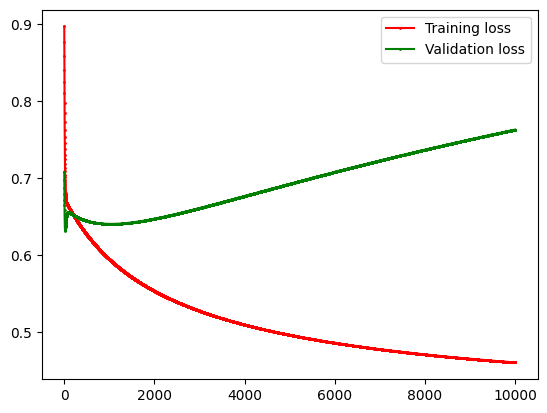

Model parameters (weights): [[-7.34655214]
 [ 2.34068626]
 [-0.2249605 ]
 [ 0.77734528]
 [10.97416402]
 [ 0.5922635 ]]
Sum of absolute values of weights: 22.255971697770907


In [11]:
# Use the LinearModel to fit the data

from model.linear_model import LinearModel
from model.metrics import accuracy,logloss
from model.gradients import logloss_sigmoid_grad
from model.utils import *
from model.activations import sigmoid

# Model configuration
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

np.random.seed(seed)
model = LinearModel(dim=X_train.shape[1], is_reg=False, loss_fn=loss_fn, act_fn=act_fn, grad_fn=grad_fn)
model.fit(X_train, y_train,lr=0.1, n_iteration =10000,val_ratio=0.2)

# print model parameters
print("Model parameters (weights):", model.W)
# sum of absolute values of weights
print("Sum of absolute values of weights:", np.sum(np.abs(model.W)))

## Task 4: Metrics

Model Evaluation
  Accuracy: 0.8533
 Precision: 0.9385
    Recall: 0.7722
  F1-score: 0.8472
   AUC-ROC: 0.9126


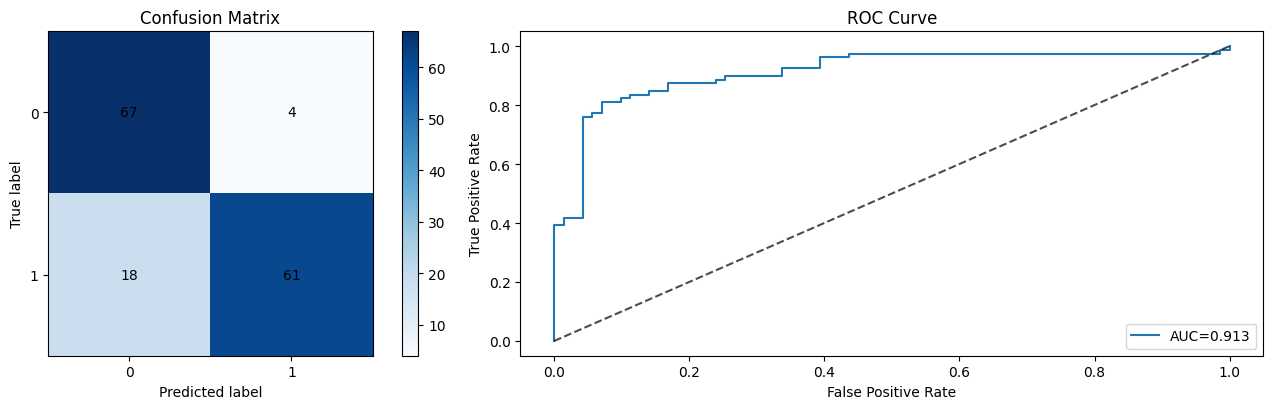

{'Accuracy': 0.8533333333333334,
 'Precision': 0.9384615384615385,
 'Recall': 0.7721518987341772,
 'F1-score': 0.8472222222222222,
 'AUC-ROC': 0.9126403993581742}

In [12]:
# use evaluate_binary_classifier to evaluate the model on the test set
from model.metrics import evaluate_binary_classifier

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)
evaluate_binary_classifier(y_test, y_pred, y_proba)

## Task 5: K-fold Cross-Validation

In [ ]:
#TODO: Implement the K-fold cross validation